In [ ]:
!pip install -q torch torch-geometric pandas numpy matplotlib scikit-learn joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from google.colab import files
import joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00


In [2]:
uploaded = files.upload()
csv_filename = list(uploaded.keys())[0]
df = pd.read_csv(csv_filename)

if 'sample_index' in df.columns:
    df = df.drop(columns=['sample_index'])
df = df.select_dtypes(include=[np.number])

# fill missing and scale
df = df.interpolate().fillna(method='bfill').fillna(method='ffill')
scaler = StandardScaler()
X = scaler.fit_transform(df.values)

n_samples, n_features = X.shape
print("Shape:", X.shape)

Saving 0000.csv to 0000.csv
Shape: (32399, 11)


/tmp/ipython-input-33519361.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate().fillna(method='bfill').fillna(method='ffill')


In [ ]:
# 2. Create adjacency (fully-connected or correlation-based)
corr = np.corrcoef(X.T)
threshold = 0.3 
adj = np.where(np.abs(corr) > threshold, 1, 0)
np.fill_diagonal(adj, 1)

edge_index = torch.tensor(np.array(np.nonzero(adj)), dtype=torch.long)

In [ ]:
class GNNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(GNNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

class GNNDecoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GNNDecoder, self).__init__()
        self.fc1 = nn.Linear(in_channels, out_channels)
    def forward(self, x):
        return self.fc1(x)

class GNNAutoEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(GNNAutoEncoder, self).__init__()
        self.encoder = GNNEncoder(in_channels, hidden_channels)
        self.decoder = GNNDecoder(hidden_channels // 2, in_channels)
    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        x_hat = self.decoder(z)
        return x_hat, z

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNAutoEncoder(in_channels=n_features, hidden_channels=64).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

x_tensor = torch.tensor(X, dtype=torch.float).to(device)
edge_index = edge_index.to(device)

epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    x_hat, _ = model(x_tensor, edge_index)
    loss = criterion(x_hat, x_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [10/100], Loss: 0.933715
Epoch [20/100], Loss: 0.760598
Epoch [30/100], Loss: 0.611461
Epoch [40/100], Loss: 0.480788
Epoch [50/100], Loss: 0.371548
Epoch [60/100], Loss: 0.282943
Epoch [70/100], Loss: 0.211858
Epoch [80/100], Loss: 0.156606
Epoch [90/100], Loss: 0.114727
Epoch [100/100], Loss: 0.085011


In [ ]:
model.eval()
with torch.no_grad():
    x_hat, _ = model(x_tensor, edge_index)
recon_error = torch.mean((x_tensor - x_hat) ** 2, dim=1).cpu().numpy()

threshold = np.percentile(recon_error, 98)
anomalies = recon_error > threshold

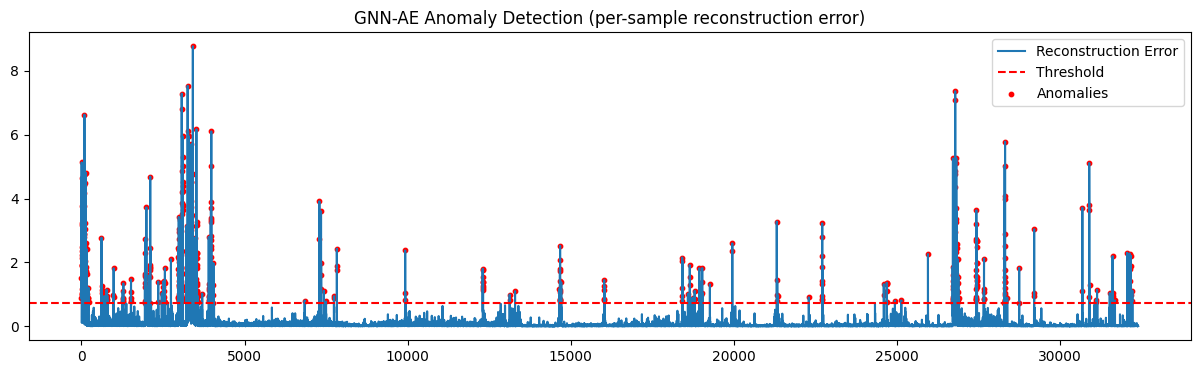

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(recon_error, label='Reconstruction Error')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
plt.scatter(np.where(anomalies)[0], recon_error[anomalies], color='red', s=10, label='Anomalies')
plt.title("GNN-AE Anomaly Detection (per-sample reconstruction error)")
plt.legend()
plt.show()


In [ ]:
torch.save(model.state_dict(), "gnn_ae_model.pt")
joblib.dump(scaler, "gnn_ae_scaler.pkl")
files.download("gnn_ae_model.pt")
files.download("gnn_ae_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_out = df.copy()
df_out['recon_error'] = recon_error
df_out['is_anomaly'] = anomalies.astype(int)
df_out.to_csv("gnn_ae_anomalies.csv", index=False)
files.download("gnn_ae_anomalies.csv")

print("GNN-AE completed and saved results.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GNN-AE completed and saved results.
